Predictions — RSSI + SNR coverage maps
=======================================
Loads the artifacts saved by `train_model.ipynb` (never refits anything) and
evaluates the fitted path-loss + heteroscedastic GPR pipelines, for BOTH RSSI
and SNR, over a dense grid covering the full greenhouse — for a single,
fixed gateway at the origin (0, 0).

For searching over multiple/alternative gateway positions, see
`optimization.ipynb` instead — this notebook is just "how good is coverage
right now".

1. Imports + load model artifacts

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

OUTPUT_ROOT = Path("outputs")
CLEAN_DATA_DIR = OUTPUT_ROOT / "clean_data"
MODEL_DIR = OUTPUT_ROOT / "model"
PREDICTION_OUTPUT_DIR = OUTPUT_ROOT / "predictions_and_maps"
PREDICTION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:

# Coordinate scaler is shared, both RSSI and SNR GPR were fitted on the same
# scaled (x_m, y_m) coordinates
scaler = joblib.load(MODEL_DIR / "coord_scaler_full_dataset.pkl")

# RSSI
coeffs_full = joblib.load(MODEL_DIR / "pathloss_coeffs_full_dataset.pkl")
gpr_hetero = joblib.load(MODEL_DIR / "gpr_hetero_final_candidate.pkl")

# SNR
coeffs_snr = joblib.load(MODEL_DIR / "pathloss_coeffs_snr_full_dataset.pkl")
gpr_hetero_snr = joblib.load(MODEL_DIR / "gpr_hetero_snr_final_candidate.pkl")

print('RSSI pathloss coeffs [intercept, log10_slope, crossing_slope]:', coeffs_full)
print('SNR  pathloss coeffs [intercept, log10_slope, crossing_slope]:', coeffs_snr)


RSSI pathloss coeffs [intercept, log10_slope, crossing_slope]: [-27.01746878 -35.3566277   -0.03728326]
SNR  pathloss coeffs [intercept, log10_slope, crossing_slope]: [ 26.18767807 -10.18908797  -0.06653518]


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


2. Reload measured packets (for the scatter overlay only — no fitting here)

In [3]:
df = pd.read_csv(CLEAN_DATA_DIR / "clean_data.csv")
df['distance'] = np.sqrt(df['x_m']**2 + df['y_m']**2)

valid = df.dropna(subset=['distance', 'rssi']).copy()
valid = valid[valid['distance'] > 0]

print(f'Measured packets available for overlay: {len(valid)}')


Measured packets available for overlay: 2748


3. Prediction grid for the full greenhouse

In [4]:
# Specific x,y for this greenhouse
x_min, x_max = -162.0, 162.0 
y_min, y_max = -138.6, 305.25
grid_res = 2.0

x_grid = np.arange(x_min, x_max + grid_res, grid_res)
y_grid = np.arange(y_min, y_max + grid_res, grid_res)
xx, yy = np.meshgrid(x_grid, y_grid)

grid_df = pd.DataFrame({'x_m': xx.ravel(), 'y_m': yy.ravel()})
print(f'Prediction grid: {len(grid_df)} points ({len(x_grid)} x {len(y_grid)})')

grid_df['distance'] = np.sqrt(grid_df['x_m']**2 + grid_df['y_m']**2)
grid_df.loc[grid_df['distance'] == 0, 'distance'] = 0.01

grid_df['row_crossings'] = (grid_df['y_m'].abs() / 1.1).round().astype(int)

log_d_grid = np.log10(grid_df['distance'].values)
crossings_grid = grid_df['row_crossings'].values

X_grid_coords = grid_df[['x_m', 'y_m']].values
X_grid_scaled = scaler.transform(X_grid_coords)


Prediction grid: 36349 points (163 x 223)


4. RSSI

In [5]:
X_pl_grid = np.column_stack([np.ones(len(grid_df)), log_d_grid, crossings_grid])
grid_df['pl_pred'] = X_pl_grid @ coeffs_full

gpr_mean, gpr_std = gpr_hetero.predict(X_grid_scaled, return_std=True)
grid_df['gpr_residual_pred'] = gpr_mean
grid_df['gpr_std'] = gpr_std

grid_df['rssi_pred'] = grid_df['pl_pred'] + grid_df['gpr_residual_pred']

print(grid_df[['x_m', 'y_m', 'pl_pred', 'gpr_residual_pred', 'rssi_pred', 'gpr_std']].describe())


                x_m           y_m       pl_pred  gpr_residual_pred  \
count  36349.000000  36349.000000  36349.000000       3.634900e+04   
mean       0.000000     83.400000   -107.447816      -7.127319e-02   
std       94.107617    128.749587     11.394882       1.944631e+00   
min     -162.000000   -138.600000   -127.142363      -1.233164e+01   
25%      -82.000000    -28.600000   -116.199837      -1.195614e-01   
50%        0.000000     83.400000   -107.494715       8.368424e-09   
75%       82.000000    195.400000   -101.024604       7.060859e-03   
max      162.000000    305.400000    -19.210928       1.480837e+01   

          rssi_pred       gpr_std  
count  36349.000000  36349.000000  
mean    -107.519089      4.621958  
std       11.600303      0.665302  
min     -127.142363      0.857519  
25%     -116.155994      4.381648  
50%     -107.948026      5.008210  
75%     -102.036667      5.008295  
max      -29.038717      5.008295  


RSSI Heatmap + Uncertainty Map

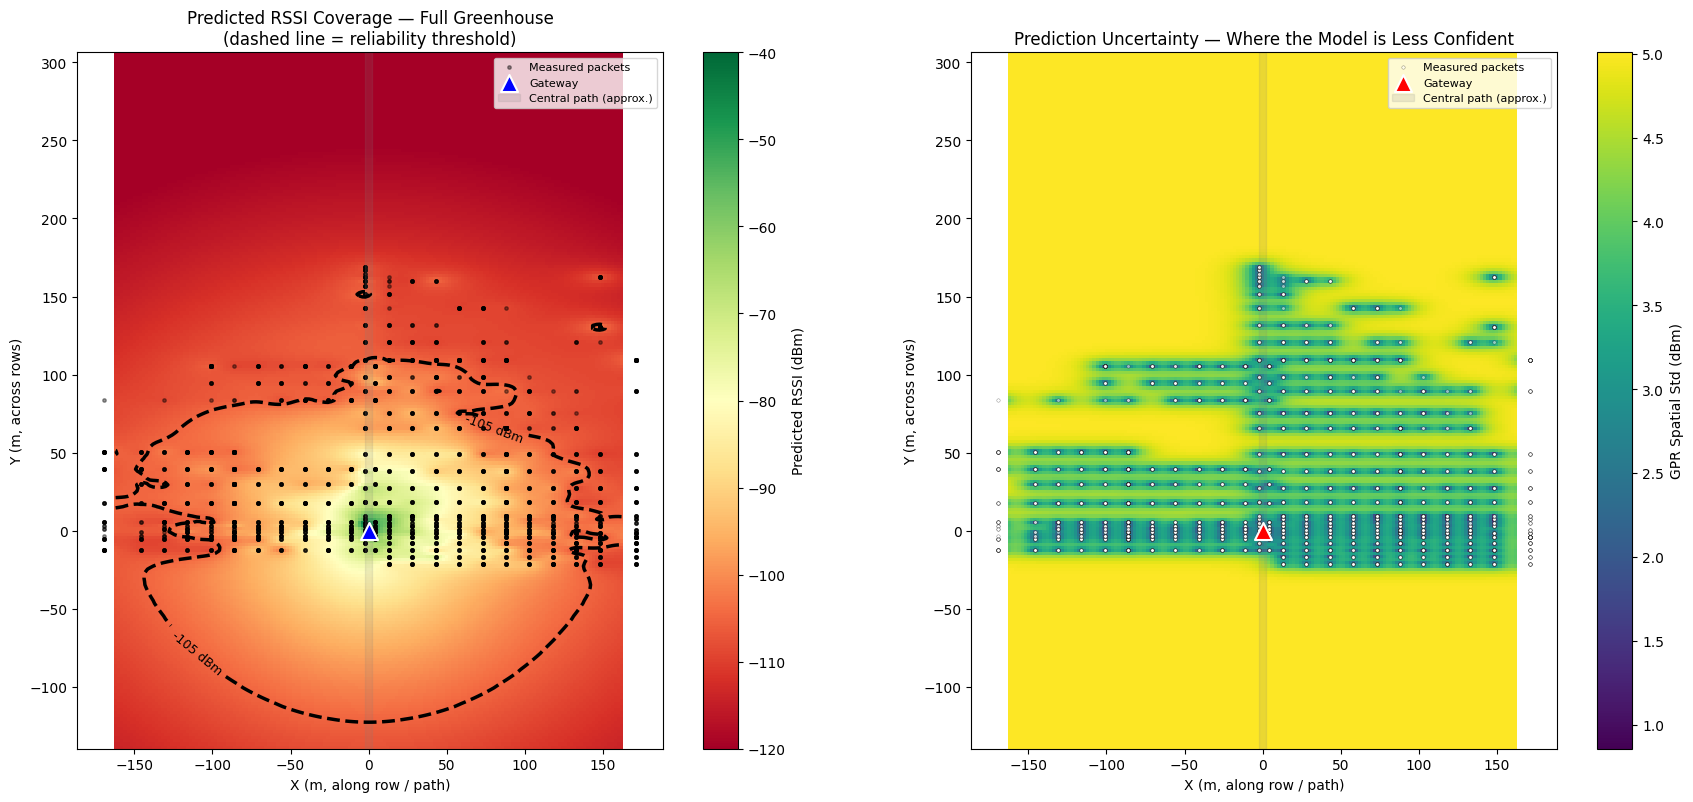

In [6]:
rssi_grid = grid_df['rssi_pred'].values.reshape(xx.shape)
std_grid = grid_df['gpr_std'].values.reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

threshold_dbm = -105  # adjust to your target SF's sensitivity and desired margin

#1. Predicted RSSI coverage
im1 = axes[0].pcolormesh(xx, yy, rssi_grid, cmap='RdYlGn', shading='auto',
                           vmin=-120, vmax=-40)
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Predicted RSSI (dBm)')

contour1 = axes[0].contour(xx, yy, rssi_grid, levels=[threshold_dbm],
                             colors='black', linewidths=2.5, linestyles='--')
axes[0].clabel(contour1, fmt=f'{threshold_dbm} dBm', fontsize=9)

axes[0].scatter(valid['x_m'], valid['y_m'], c='black', s=6, alpha=0.4,
                 label='Measured packets')
axes[0].scatter(0, 0, c='blue', s=150, marker='^', edgecolor='white',
                 linewidth=1.5, label='Gateway', zorder=5)
axes[0].axvspan(-2, 2, color='grey', alpha=0.15, label='Central path (approx.)')

axes[0].set_xlabel('X (m, along row / path)')
axes[0].set_ylabel('Y (m, across rows)')
axes[0].set_title('Predicted RSSI Coverage — Full Greenhouse\n(dashed line = reliability threshold)')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_aspect('equal')

# 2. Prediction uncertainty
im2 = axes[1].pcolormesh(xx, yy, std_grid, cmap='viridis', shading='auto')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('GPR Spatial Std (dBm)')

axes[1].scatter(valid['x_m'], valid['y_m'], c='white', s=6, alpha=0.5,
                 edgecolor='black', linewidth=0.3, label='Measured packets')
axes[1].scatter(0, 0, c='red', s=150, marker='^', edgecolor='white',
                 linewidth=1.5, label='Gateway', zorder=5)
axes[1].axvspan(-2, 2, color='grey', alpha=0.15, label='Central path (approx.)')

axes[1].set_xlabel('X (m, along row / path)')
axes[1].set_ylabel('Y (m, across rows)')
axes[1].set_title('Prediction Uncertainty — Where the Model is Less Confident')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig(PREDICTION_OUTPUT_DIR / 'coverage_heatmap_full_greenhouse.png', dpi=150, bbox_inches='tight')
plt.show()


5. SNR — predict over the grid

In [7]:
X_pl_grid_snr = np.column_stack([np.ones(len(grid_df)), log_d_grid, crossings_grid])
grid_df['snr_pl_pred'] = X_pl_grid_snr @ coeffs_snr

gpr_mean_snr, gpr_std_snr = gpr_hetero_snr.predict(X_grid_scaled, return_std=True)
grid_df['gpr_residual_pred_snr'] = gpr_mean_snr
grid_df['gpr_std_snr'] = gpr_std_snr
grid_df['snr_pred'] = grid_df['snr_pl_pred'] + grid_df['gpr_residual_pred_snr']

print(grid_df[['x_m', 'y_m', 'snr_pl_pred', 'gpr_residual_pred_snr', 'snr_pred', 'gpr_std_snr']].describe())


                x_m           y_m   snr_pl_pred  gpr_residual_pred_snr  \
count  36349.000000  36349.000000  36349.000000           36349.000000   
mean       0.000000     83.400000     -3.436997              -0.079381   
std       94.107617    128.749587      7.420660               2.621629   
min     -162.000000   -138.600000    -18.176220             -11.873209   
25%      -82.000000    -28.600000     -9.371683              -0.082456   
50%        0.000000     83.400000     -2.533205               0.036705   
75%       82.000000    195.400000      2.247509               0.677602   
max      162.000000    305.400000     28.381579               9.083280   

           snr_pred   gpr_std_snr  
count  36349.000000  36349.000000  
mean      -3.516377      3.965221  
std        7.914249      1.121508  
min      -18.175666      0.548206  
25%       -8.905586      2.836125  
50%       -4.017779      4.747577  
75%        1.267627      4.851619  
max       19.372679      4.852141  


SNR Heatmap + Uncertainty Map

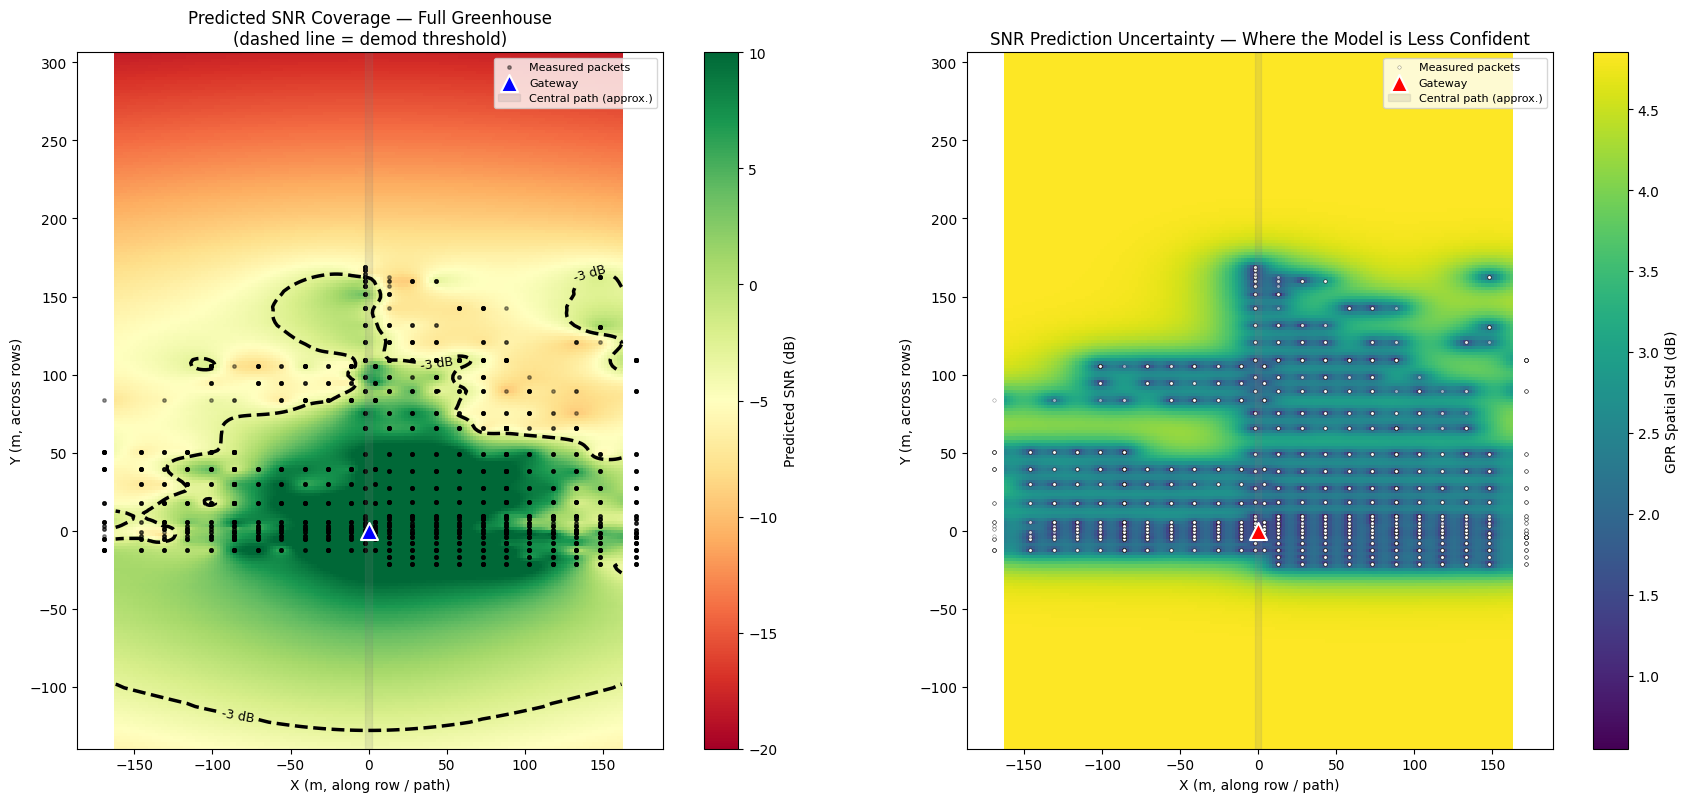

In [8]:
snr_grid = grid_df['snr_pred'].values.reshape(xx.shape)
snr_std_grid = grid_df['gpr_std_snr'].values.reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

threshold_db = -3  # adjust to your target SF's SNR demodulation floor

# Predicted SNR coverage
im1 = axes[0].pcolormesh(xx, yy, snr_grid, cmap='RdYlGn', shading='auto',
                           vmin=-20, vmax=10)
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Predicted SNR (dB)')

contour1 = axes[0].contour(xx, yy, snr_grid, levels=[threshold_db],
                             colors='black', linewidths=2.5, linestyles='--')
axes[0].clabel(contour1, fmt=f'{threshold_db} dB', fontsize=9)

axes[0].scatter(valid['x_m'], valid['y_m'], c='black', s=6, alpha=0.4,
                 label='Measured packets')
axes[0].scatter(0, 0, c='blue', s=150, marker='^', edgecolor='white',
                 linewidth=1.5, label='Gateway', zorder=5)
axes[0].axvspan(-2, 2, color='grey', alpha=0.15, label='Central path (approx.)')

axes[0].set_xlabel('X (m, along row / path)')
axes[0].set_ylabel('Y (m, across rows)')
axes[0].set_title('Predicted SNR Coverage — Full Greenhouse\n(dashed line = demod threshold)')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_aspect('equal')

# SNR prediction uncertainty
im2 = axes[1].pcolormesh(xx, yy, snr_std_grid, cmap='viridis', shading='auto')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('GPR Spatial Std (dB)')

axes[1].scatter(valid['x_m'], valid['y_m'], c='white', s=6, alpha=0.5,
                 edgecolor='black', linewidth=0.3, label='Measured packets')
axes[1].scatter(0, 0, c='red', s=150, marker='^', edgecolor='white',
                 linewidth=1.5, label='Gateway', zorder=5)
axes[1].axvspan(-2, 2, color='grey', alpha=0.15, label='Central path (approx.)')

axes[1].set_xlabel('X (m, along row / path)')
axes[1].set_ylabel('Y (m, across rows)')
axes[1].set_title('SNR Prediction Uncertainty — Where the Model is Less Confident')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig(PREDICTION_OUTPUT_DIR / 'coverage_heatmap_snr_full_greenhouse.png', dpi=150, bbox_inches='tight')
plt.show()


6. Combined reliable coverage (RSSI AND SNR both above threshold)

Grid points with reliable coverage: 32.5%


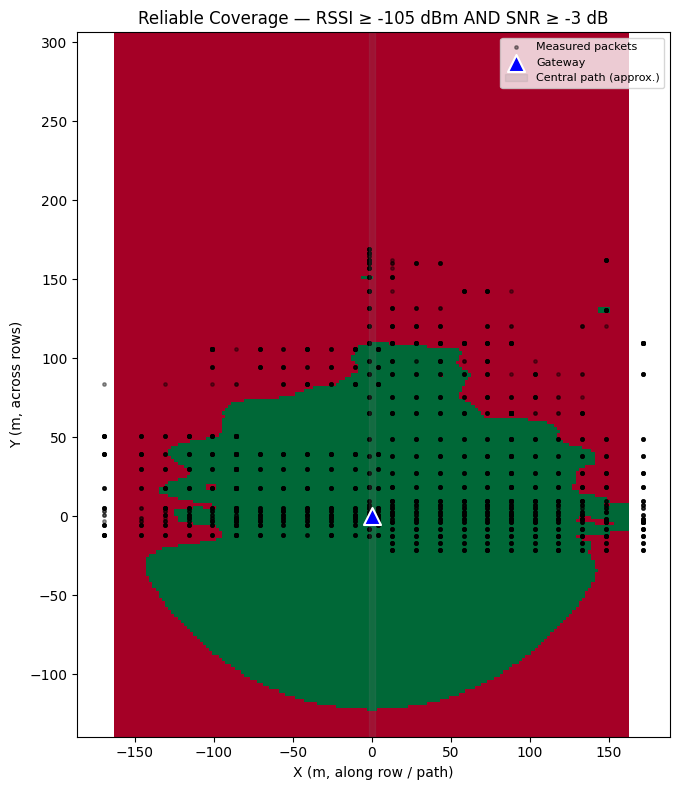

In [9]:
reliable = (rssi_grid >= threshold_dbm) & (snr_grid >= threshold_db)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(xx, yy, reliable.astype(int), cmap='RdYlGn', shading='auto', vmin=0, vmax=1)

ax.scatter(valid['x_m'], valid['y_m'], c='black', s=6, alpha=0.4, label='Measured packets')
ax.scatter(0, 0, c='blue', s=150, marker='^', edgecolor='white', linewidth=1.5,
           label='Gateway', zorder=5)
ax.axvspan(-2, 2, color='grey', alpha=0.15, label='Central path (approx.)')

ax.set_xlabel('X (m, along row / path)')
ax.set_ylabel('Y (m, across rows)')
ax.set_title(f'Reliable Coverage — RSSI \u2265 {threshold_dbm} dBm AND SNR \u2265 {threshold_db} dB')
ax.legend(loc='upper right', fontsize=8)
ax.set_aspect('equal')

reliable_pct = 100 * reliable.mean()
print(f'Grid points with reliable coverage: {reliable_pct:.1f}%')

plt.tight_layout()
plt.savefig(PREDICTION_OUTPUT_DIR / 'reliable_coverage_full_greenhouse.png', dpi=150, bbox_inches='tight')
plt.show()


7. Validation — Path-Loss Only vs. Path-Loss + GPR (RSSI)

Uses the honest held-out CV results saved by `train_model.ipynb` — no refitting here, just loading `cv_fold_rmse_hetero.pkl` / `cv_pred_residual_hetero.pkl` / `cv_pred_std_hetero.pkl` and comparing them against the path-loss-only baseline on the measured packets.

In [10]:
from sklearn.metrics import mean_squared_error

# Path-loss baseline RMSE (already computed during training)
pathloss_summary = joblib.load(MODEL_DIR / "pathloss_summary_full_dataset.pkl")
pl_rmse = pathloss_summary['rmse_full']

# Honest held-out CV results for the heteroscedastic GPR (RSSI)
fold_rmse_hetero = joblib.load(MODEL_DIR / "cv_fold_rmse_hetero.pkl")
cv_pred_residual_hetero = joblib.load(MODEL_DIR / "cv_pred_residual_hetero.pkl")
cv_pred_std_hetero = joblib.load(MODEL_DIR / "cv_pred_std_hetero.pkl")

cv_rmse_mean = np.mean(fold_rmse_hetero)
cv_rmse_std = np.std(fold_rmse_hetero)

# Path-loss prediction on the measured packets (same row_crossings definition as training)
valid['row_crossings'] = (valid['y_m'].abs() / 1.65).round().astype(int)
log_d = np.log10(valid['distance'].values)
crossings = valid['row_crossings'].values
X_pl_full = np.column_stack([np.ones(len(valid)), log_d, crossings])

pl_pred_rssi = X_pl_full @ coeffs_full
actual_rssi = valid['rssi'].values

print(f'Path-Loss Only RMSE                : {pl_rmse:.3f} dBm')
print(f'Path-Loss + GPR CV RMSE (held-out)  : {cv_rmse_mean:.3f} ± {cv_rmse_std:.3f} dBm')

Path-Loss Only RMSE                : 6.350 dBm
Path-Loss + GPR CV RMSE (held-out)  : 5.796 ± 0.496 dBm


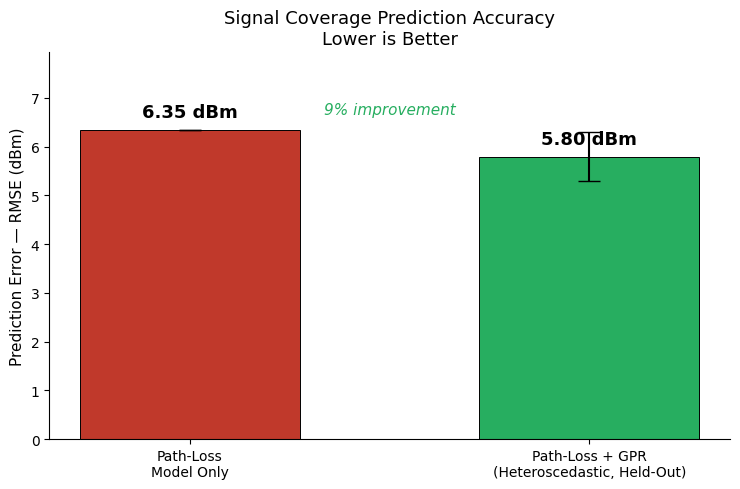

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 5))

labels = ['Path-Loss\nModel Only', 'Path-Loss + GPR\n(Heteroscedastic, Held-Out)']
values = [pl_rmse, cv_rmse_mean]
errors = [0, cv_rmse_std]
colors = ['#c0392b', '#27ae60']

bars = ax.bar(labels, values, yerr=errors, capsize=8, color=colors,
               edgecolor='black', linewidth=0.7, width=0.55)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.25, f'{val:.2f} dBm',
            ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel('Prediction Error — RMSE (dBm)', fontsize=11)
ax.set_title('Signal Coverage Prediction Accuracy\nLower is Better', fontsize=13)
ax.set_ylim(0, max(values) * 1.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

improvement_pct = 100 * (pl_rmse - cv_rmse_mean) / pl_rmse
ax.annotate(f'{improvement_pct:.0f}% improvement',
            xy=(0.5, max(values) * 1.05), ha='center', fontsize=11,
            style='italic', color='#27ae60')

plt.tight_layout()
plt.savefig(PREDICTION_OUTPUT_DIR / 'presentation_rmse_comparison_hetero.png', dpi=200, bbox_inches='tight')
plt.show()

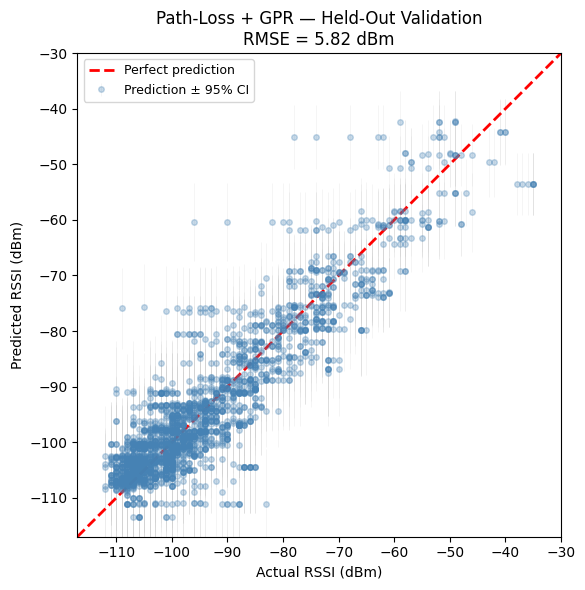

In [12]:
cv_pred_rssi_hetero = pl_pred_rssi + cv_pred_residual_hetero
cv_rmse_check = np.sqrt(mean_squared_error(actual_rssi, cv_pred_rssi_hetero))

fig, ax = plt.subplots(figsize=(7, 6))

lims = [actual_rssi.min() - 5, actual_rssi.max() + 5]

# Per-point error bars using each point's own predictive std (95%~1.96*std)
ax.errorbar(actual_rssi, cv_pred_rssi_hetero, yerr=1.96 * cv_pred_std_hetero,
            fmt='o', alpha=0.3, markersize=4, elinewidth=0.5, capsize=0,
            color='steelblue', ecolor='lightgray', label='Prediction ± 95% CI')

ax.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Actual RSSI (dBm)')
ax.set_ylabel('Predicted RSSI (dBm)')
ax.set_title(f'Path-Loss + GPR — Held-Out Validation\nRMSE = {cv_rmse_check:.2f} dBm')
ax.legend(loc='upper left', fontsize=9)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(PREDICTION_OUTPUT_DIR / 'presentation_scatter_with_ci.png', dpi=200, bbox_inches='tight')
plt.show()

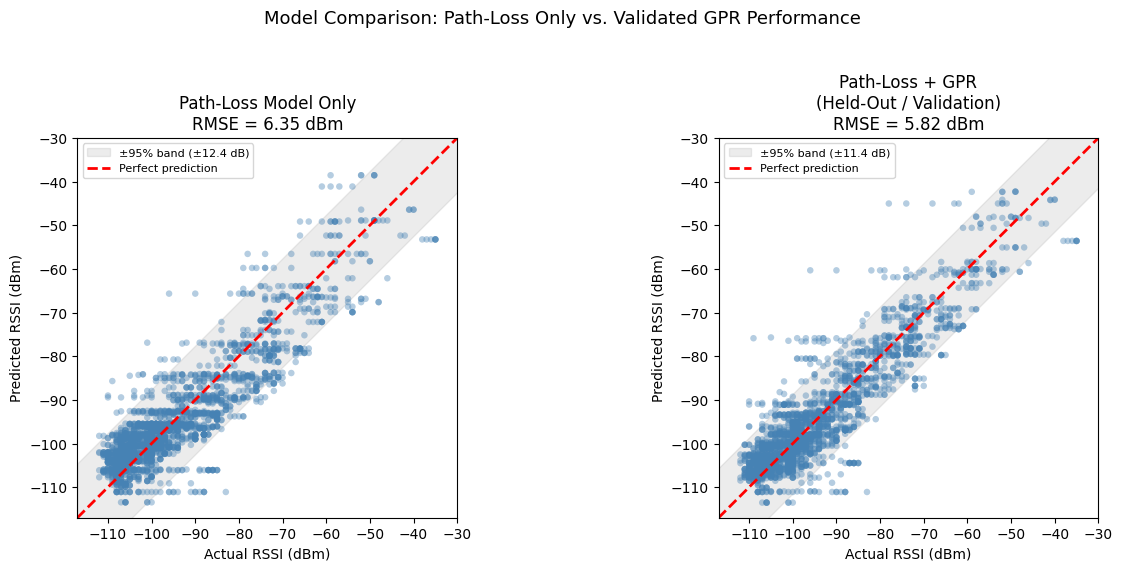

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

panels = [
    (pl_pred_rssi, 'Path-Loss Model Only', pl_rmse),
    (cv_pred_rssi_hetero, 'Path-Loss + GPR\n(Held-Out / Validation)', cv_rmse_check),
]

for ax, (pred, title, rmse_val) in zip(axes, panels):
    lims = [actual_rssi.min() - 5, actual_rssi.max() + 5]
    line_x = np.linspace(lims[0], lims[1], 100)

    # use this model's own RMSE as the margin
    band_95 = 1.96 * rmse_val
    ax.fill_between(line_x, line_x - band_95, line_x + band_95,
                     color='gray', alpha=0.15, label=f'±95% band (±{band_95:.1f} dB)')

    ax.scatter(actual_rssi, pred, alpha=0.4, s=22, color='steelblue', edgecolor='none')
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Actual RSSI (dBm)')
    ax.set_ylabel('Predicted RSSI (dBm)')
    ax.set_title(f'{title}\nRMSE = {rmse_val:.2f} dBm')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_aspect('equal')

plt.suptitle('Model Comparison: Path-Loss Only vs. Validated GPR Performance', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(PREDICTION_OUTPUT_DIR / 'presentation_scatter_2panel_hetero.png', dpi=200, bbox_inches='tight')
plt.show()